In [1]:
# Figure1(A-D)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
from matplotlib.font_manager import FontProperties
import pyscisci.all as pyscisci
from brokenaxes import brokenaxes
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from scipy import stats
from scipy.stats import norm, ks_2samp
from adjustText import adjust_text
# 定义字体
EF = FontProperties(family = 'DejaVu Sans')

%matplotlib inline

In [2]:
main_path = r'/home/20250114zmz_kd/'

In [3]:
basic_performance = r'Co-utilization/2-Revision202501-DataVisualize/2-BasicPerformanceGaps.csv'
bp_df = pd.read_csv(main_path + basic_performance)
del bp_df['Unnamed: 0']
print(bp_df .shape)
bp_df .columns

(212735, 14)


Index(['work_id', 'PublishedYear', 'numfacility', 'C1N0', 'Facility',
       'times_cited_3', 'times_cited_5', 'times_cited_10', 'num_reference',
       'di3', 'di5', 'di10', 'NoveltyScore', 'ConventionalityScore'],
      dtype='object')

In [13]:
c1n0 = bp_df[['work_id','PublishedYear','C1N0','num_reference',
              'times_cited_3', 'times_cited_5',
              'di3', 'di5']]
c1n0 .shape

(212735, 8)

In [14]:
c1n0_tc3 = c1n0[['work_id','PublishedYear','C1N0','times_cited_3']]
c1n0_tc3 = c1n0_tc3[c1n0_tc3['PublishedYear']<=2021]
print(c1n0_tc3 .shape)
c1n0_tc3 = c1n0_tc3.dropna()
print(c1n0_tc3 .shape)

(185663, 4)
(185663, 4)


In [15]:
c1n0_tc5 = c1n0[['work_id','PublishedYear','C1N0','times_cited_5']]
c1n0_tc5 = c1n0_tc5[c1n0_tc5['PublishedYear']<=2019]
print(c1n0_tc5 .shape)
c1n0_tc5 = c1n0_tc5.dropna()
print(c1n0_tc5 .shape)

(156562, 4)
(156562, 4)


In [16]:
c1n0_di3 = c1n0[['work_id','PublishedYear','C1N0','times_cited_3','num_reference','di3']]
c1n0_di3 = c1n0_di3[(c1n0_di3['times_cited_3']>=5) & (c1n0_di3['num_reference']>=5) & (c1n0_di3['PublishedYear']<=2021)]
print(c1n0_di3 .shape)
c1n0_di3 = c1n0_di3 .dropna()
print(c1n0_di3 .shape)

(132749, 6)
(132749, 6)


In [17]:
c1n0_di5 = c1n0[['work_id','PublishedYear','C1N0','times_cited_5','num_reference','di5']]
c1n0_di5 = c1n0_di5[(c1n0_di5['times_cited_5']>=5) & (c1n0_di5['num_reference']>=5) & (c1n0_di5['PublishedYear']<=2019)]
print(c1n0_di5 .shape)
c1n0_di5 = c1n0_di5 .dropna()
print(c1n0_di5 .shape)

(124266, 6)
(124266, 6)


In [18]:
from scipy.stats import ttest_ind

def significance_marker(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.1:
        return '*'
    else:
        return ''

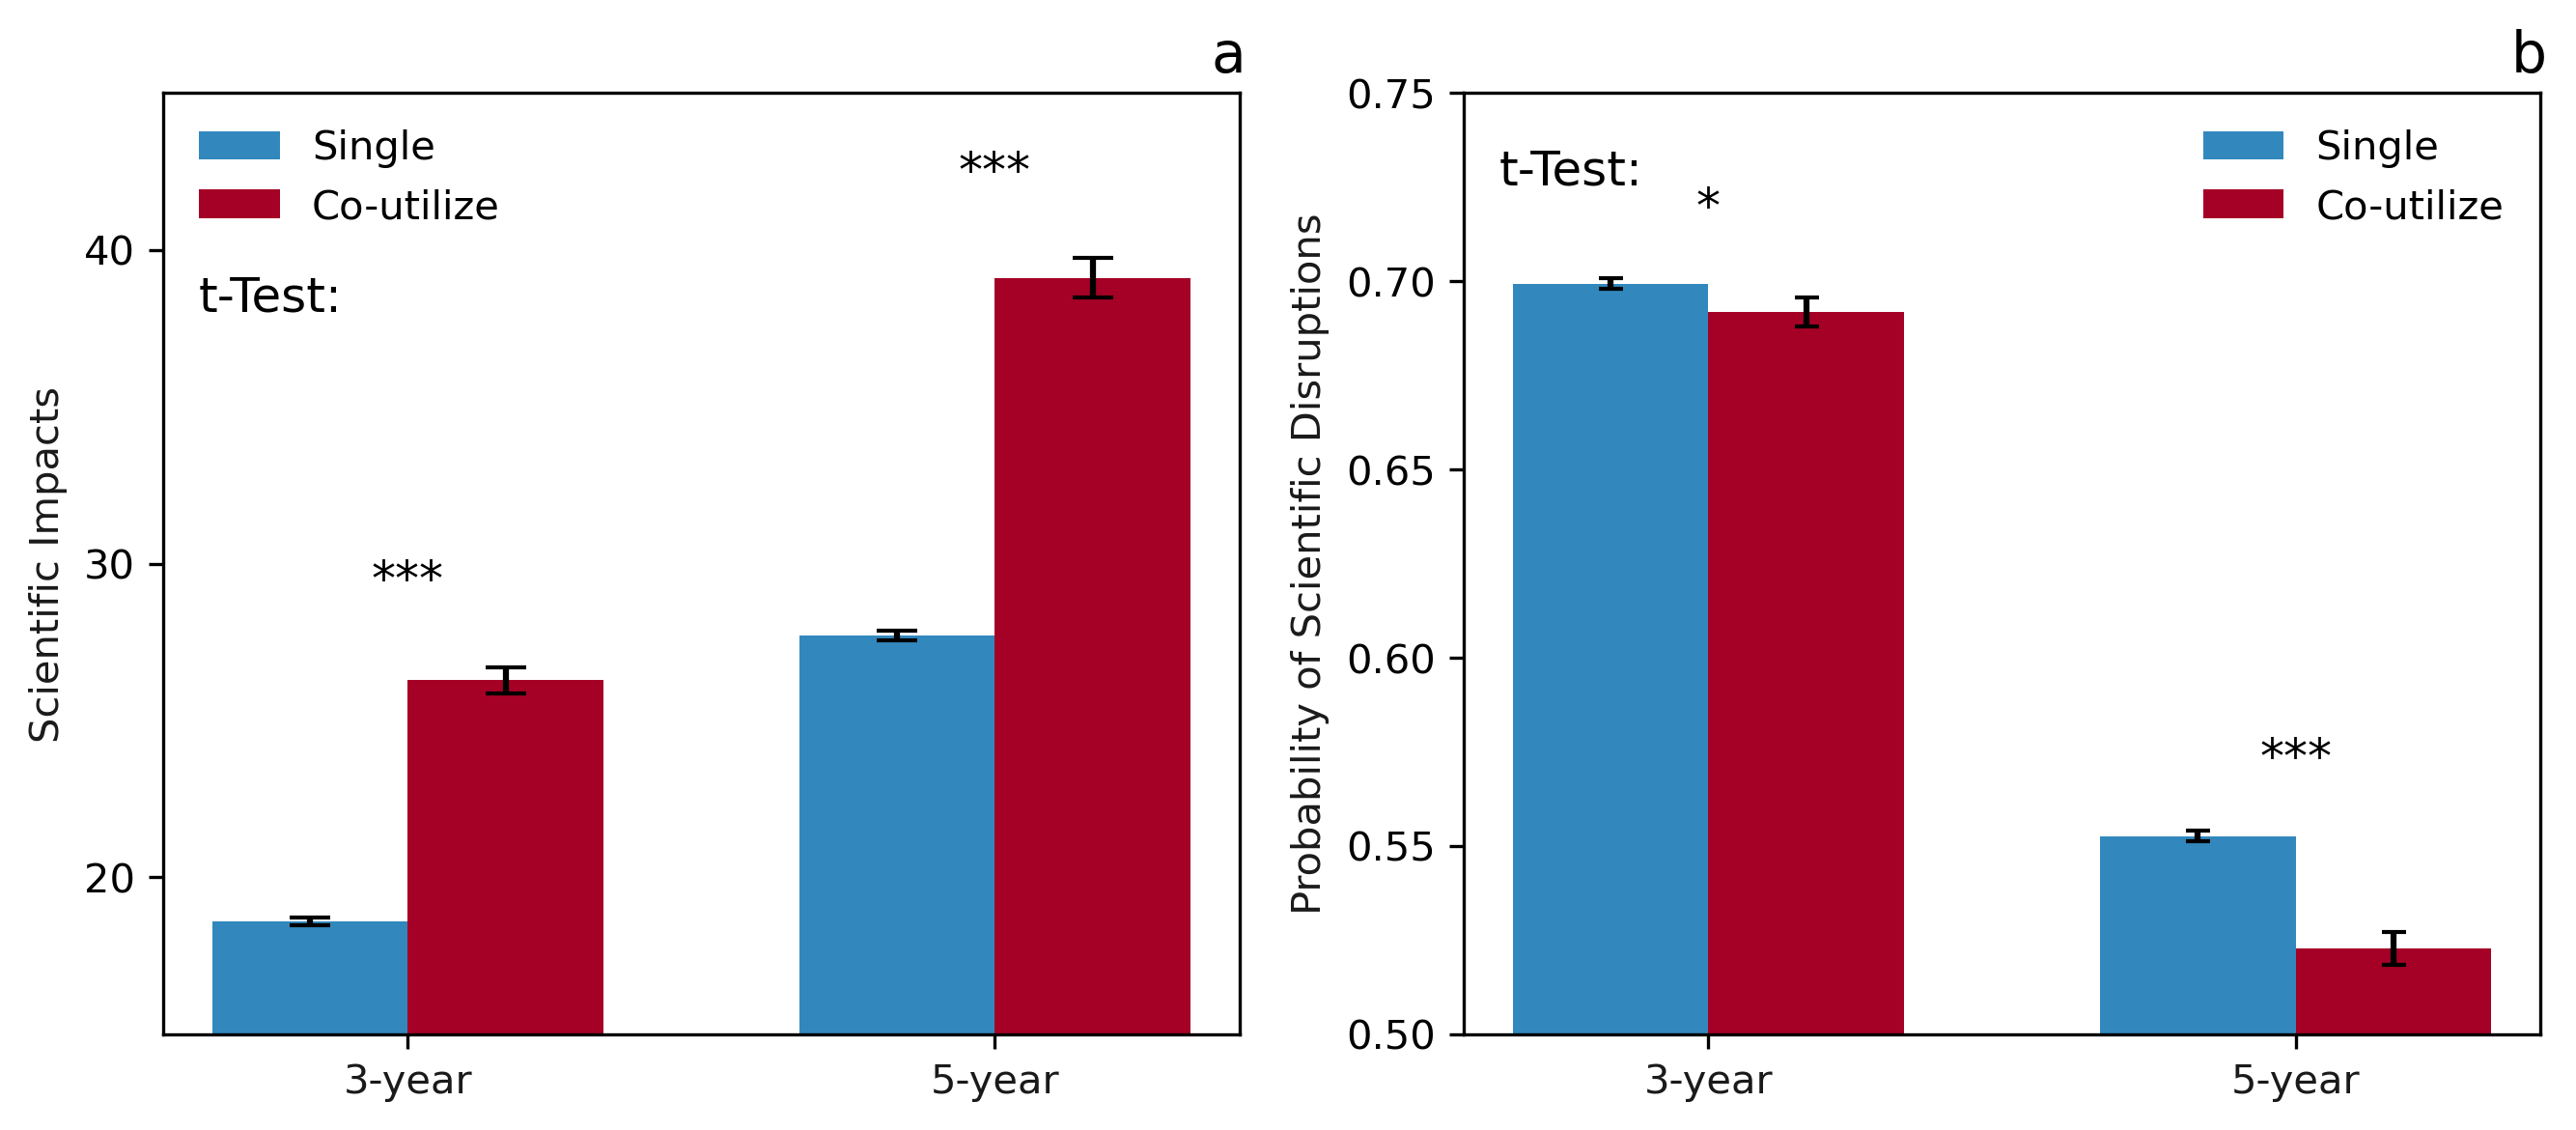

In [19]:
fig, axes = plt.subplots(1,2, figsize = (9,4), dpi = 300)
df00 = c1n0_tc3.groupby('C1N0')['times_cited_3'].agg(['mean', 'sem',]).reset_index()
df01 = c1n0_tc5.groupby('C1N0')['times_cited_5'].agg(['mean', 'sem',]).reset_index()

axes[0].bar(1, df00.loc[df00['C1N0']==0, 'mean'], yerr=df00.loc[df00['C1N0']==0, 'sem'], color = '#3288bd', label = 'Single', width=1, capsize=5)
axes[0].bar(2, df00.loc[df00['C1N0']==1, 'mean'], yerr=df00.loc[df00['C1N0']==1, 'sem'], color = '#a50026', label = 'Co-utilize', width = 1, capsize=5)
axes[0].bar(4, df01.loc[df01['C1N0']==0, 'mean'], yerr=df01.loc[df01['C1N0']==0, 'sem'], color = '#3288bd', width = 1, capsize=5)
axes[0].bar(5, df01.loc[df01['C1N0']==1, 'mean'], yerr=df01.loc[df01['C1N0']==1, 'sem'], color = '#a50026', width = 1, capsize=5)

axes[0].set_ylabel('Scientific Impacts', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[0].set_xticks([1.5, 4.5])
axes[0].set_xticklabels(['3-year','5-year'], fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[0].legend(frameon=False, prop={'family': EF.get_name(), 'size': 10}, loc='upper left')
axes[0].set_ylim(15, 45)
axes[0].yaxis.set_major_locator(MultipleLocator(10))

p3 = ttest_ind(c1n0_tc3.loc[c1n0_tc3['C1N0']==0, 'times_cited_3'],
               c1n0_tc3.loc[c1n0_tc3['C1N0']==1, 'times_cited_3'],
               equal_var=False).pvalue
axes[0].text(1.5, max(df00['mean'])+df00['sem'].max()+2, significance_marker(p3),
             ha='center', va='bottom', fontsize=12)
# 5-year
p5 = ttest_ind(c1n0_tc5.loc[c1n0_tc5['C1N0']==0, 'times_cited_5'],
               c1n0_tc5.loc[c1n0_tc5['C1N0']==1, 'times_cited_5'],
               equal_var=False).pvalue
axes[0].text(4.5, max(df01['mean'])+df01['sem'].max()+2, significance_marker(p5),
             ha='center', va='bottom', fontsize=12)
axes[0].text(0.8, max(df01['mean'])+df01['sem'].max()-2, 't-Test:',
             ha='center', va='bottom', fontsize=12)

df10 = c1n0_di3.groupby(['C1N0']).agg({
    'di3': lambda x: (x >= 0).mean()
}).reset_index()
df11 = c1n0_di5.groupby(['C1N0']).agg({
    'di5': lambda x: (x >= 0).mean()
}).reset_index()

df10 = c1n0_di3.assign(ind=(c1n0_di3['di3'] >= 0).astype(int)) \
    .groupby('C1N0')['ind'] \
    .agg(['mean','count']) \
    .reset_index()
df10['sem'] = (df10['mean']*(1-df10['mean'])/df10['count'])**0.5
df11 = c1n0_di5.assign(ind=(c1n0_di5['di5'] >= 0).astype(int)) \
    .groupby('C1N0')['ind'] \
    .agg(['mean','count']) \
    .reset_index()
df11['sem'] = (df11['mean']*(1-df11['mean'])/df11['count'])**0.5

axes[1].bar(1, df10.loc[df10['C1N0']==0, 'mean'], yerr=df10.loc[df10['C1N0']==0, 'sem'], color = '#3288bd', label = 'Single', width = 1, capsize=3)
axes[1].bar(2, df10.loc[df10['C1N0']==1, 'mean'], yerr=df10.loc[df10['C1N0']==1, 'sem'], color = '#a50026', label = 'Co-utilize', width = 1, capsize=3)
axes[1].bar(4, df11.loc[df11['C1N0']==0, 'mean'], yerr=df11.loc[df11['C1N0']==0, 'sem'], color = '#3288bd', width = 1, capsize=3)
axes[1].bar(5, df11.loc[df11['C1N0']==1, 'mean'], yerr=df11.loc[df11['C1N0']==1, 'sem'], color = '#a50026', width = 1, capsize=3)
axes[1].set_ylabel('Probability of Scientific Disruptions', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[1].set_xticks([1.5, 4.5])
axes[1].set_xticklabels(['3-year','5-year'], fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[1].legend(frameon=False, prop={'family': EF.get_name(), 'size': 10}, loc='upper right')
axes[1].set_ylim(0.5, 0.75)
axes[1].yaxis.set_major_locator(MultipleLocator(0.05))

p3d = ttest_ind((c1n0_di3['di3']>=0).astype(int)[c1n0_di3['C1N0']==0],
                (c1n0_di3['di3']>=0).astype(int)[c1n0_di3['C1N0']==1],
                equal_var=False).pvalue
axes[1].text(1.5, max(df10['mean'])+df10['sem'].max()+0.01, significance_marker(p3d),
             ha='center', va='bottom', fontsize=12)
# 5-year
p5d = ttest_ind((c1n0_di5['di5']>=0).astype(int)[c1n0_di5['C1N0']==0],
                (c1n0_di5['di5']>=0).astype(int)[c1n0_di5['C1N0']==1],
                equal_var=False).pvalue
axes[1].text(4.5, max(df11['mean'])+df11['sem'].max()+0.01, significance_marker(p5d),
             ha='center', va='bottom', fontsize=12)
axes[1].text(0.8, max(df10['mean'])+df10['sem'].max()+0.02, 't-Test:',
             ha='center', va='bottom', fontsize=12)
for i, ax in enumerate(axes.flat):
    ax.text(0.99, 1.01, chr(97 + i), transform=ax.transAxes, 
            fontsize=14, verticalalignment='bottom', horizontalalignment='center')

plt.tight_layout()
# plt.savefig(main_path + r'Co-utilization/2-Revision202501-DataVisualize/2-Figure-5_0911.svg')
plt.show()

In [11]:
from scipy.stats import ttest_ind

# TC3
t_stat_TC3, p_value_TC3 = ttest_ind(
    c1n0_tc3[c1n0_tc3['C1N0'] == 0]['times_cited_3'],
    c1n0_tc3[c1n0_tc3['C1N0'] == 1]['times_cited_3'],
    equal_var=False
)
print('t_stat_TC3', t_stat_TC3)
print('p_value_TC3', p_value_TC3)

# TC5
t_stat_TC5, p_value_TC5 = ttest_ind(
    c1n0_tc5[c1n0_tc5['C1N0'] == 0]['times_cited_5'],
    c1n0_tc5[c1n0_tc5['C1N0'] == 1]['times_cited_5'],
    equal_var=False
)
print('t_stat_TC5', t_stat_TC5)
print('p_value_TC5', p_value_TC5)

# DI3: 转成 0/1 指示变量
di3_ind = c1n0_di3.copy()
di3_ind['di3_gt0'] = (di3_ind['di3'] >= 0).astype(int)

t_stat_DI3, p_value_DI3 = ttest_ind(
    di3_ind[di3_ind['C1N0']==0]['di3_gt0'],
    di3_ind[di3_ind['C1N0']==1]['di3_gt0'],
    equal_var=False
)
print('t_stat_DI3', t_stat_DI3)
print('p_value_DI3', p_value_DI3)
# DI5 同理
di5_ind = c1n0_di5.copy()
di5_ind['di5_gt0'] = (di5_ind['di5'] >= 0).astype(int)
t_stat_DI5, p_value_DI5 = ttest_ind(
    di5_ind[di5_ind['C1N0']==0]['di5_gt0'],
    di5_ind[di5_ind['C1N0']==1]['di5_gt0'],
    equal_var=False
)
print('t_stat_DI5', t_stat_DI5)
print('p_value_DI5', p_value_DI5)

t_stat_TC3 -17.40427685844084
p_value_TC3 2.327841109776271e-67
t_stat_TC5 -17.591879582234366
p_value_TC5 1.1907445866810556e-68
t_stat_DI3 1.8453315006290232
p_value_DI3 0.0650054620157461
t_stat_DI5 6.422173508290564
p_value_DI5 1.3811851526127328e-10
